In [1]:
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns 
import math
from torch.utils.data import DataLoader
import torch.optim as optim
from sklearn.model_selection import train_test_split


In [2]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import  transforms, datasets
from torch.utils.data import  TensorDataset

In [3]:
import numpy
print(numpy.__version__)


1.26.4


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

train_data = datasets.MNIST(root= "./data", train = True, download=False, transform= transform)
tmp_data = datasets.MNIST(root="./data", train = False, download=False, transform = transform)

batch_size=64

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,)
tmp_loader = DataLoader(tmp_data, batch_size=batch_size, shuffle=False)

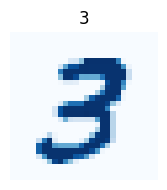

In [5]:
def show(index, datasets = train_data):
    image, label = datasets[index]
    plt.figure(figsize=(2,2))
    plt.imshow(image.squeeze(0), cmap="Blues")
    plt.title(label)
    plt.axis ("off")
    plt.tight_layout()
    plt.show()

    
show(7, train_data)

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root= "./data", train = True, download=False, transform= transform)
tmp_data = datasets.MNIST(root="./data", train = False, download=False, transform = transform)

batch_size= 256

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,)
tmp_loader = DataLoader(tmp_data, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 42

print("device:", device)
if torch.cuda.is_available():
    try:
        print("cuda device name:", torch.cuda.get_device_name(0))
    except Exception:
        pass

X_train = train_data.data.unsqueeze(1).float() 
y_train = train_data.targets.long()

X_temp = tmp_data.data.numpy()
y_temp = tmp_data.targets.numpy()

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.3, random_state=seed)

X_val = torch.from_numpy(X_val).unsqueeze(1).float() 
X_test = torch.from_numpy(X_test).unsqueeze(1).float() 

y_val = torch.from_numpy(y_val).long()
y_test = torch.from_numpy(y_test).long()

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

device: cuda
cuda device name: NVIDIA GeForce GTX 1050


In [ ]:



n_train, input_channel, height, width = X_train.shape
n_valid = len(X_val)

class simpleCNN(nn.Module):
    def __init__(self, sample_shape, input_channel, hidden_dims, output_dim, kernel_sizes, strides, paddings):
        super().__init__()
        current_channel = input_channel
        layers = []
        H, W = sample_shape
        
        for i in range(len(hidden_dims)):
            layers.append(nn.Conv2d(in_channels=current_channel, out_channels=hidden_dims[i], kernel_size=kernel_sizes[i], stride=strides[i], padding=paddings[i]))
            layers.append(nn.LeakyReLU())
            layers.append(nn.MaxPool2d(2))
            H = math.floor((H + 2 * paddings[i] - kernel_sizes[i]) / strides[i]) + 1
            W = math.floor((W + 2 * paddings[i] - kernel_sizes[i]) / strides[i]) + 1
            H = H // 2
            W = W // 2
            
            current_channel = hidden_dims[i]
        
        layers.append(nn.Flatten())
        linear_layer = nn.Linear(hidden_dims[-1] * H * W, output_dim)
        layers.append(linear_layer)
        
        self.layers = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.layers(x)

model = simpleCNN((height, width), 1, [32, 64], 10, [5, 3], [1, 1], [1, 1]).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(reduction="mean")

n_epochs = 8

for epoch in range(n_epochs):
    model.train()
    training_loss = 0.0
    
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        optimizer.zero_grad()
        train_logits = model(x_batch)
        loss = criterion(train_logits, y_batch)
        loss.backward()
        optimizer.step()
        training_loss += loss.item()
        
    training_loss /= len(train_loader)
    
    model.eval()
    val_loss_total = 0.0
    correct = 0
    
    total = 0
    
    with torch.no_grad():
        
        for x_val_batch, y_val_batch in val_loader:
            x_val_batch = x_val_batch.to(device, non_blocking=True)
            y_val_batch = y_val_batch.to(device, non_blocking=True)
            
            val_logits = model(x_val_batch)
            val_loss_total += criterion(val_logits, y_val_batch).item()
            
            preds = val_logits.argmax(dim=1)
            correct += (preds == y_val_batch).sum().item()
            total += y_val_batch.size(0)
            
    validating_loss = val_loss_total / len(val_loader)
    val_acc = correct / total
    
    if (epoch + 1) % 1 == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}] | train_loss: {training_loss:.4f} | val_loss: {validating_loss:.4f} | val_acc: {val_acc:.4f}")


device: cuda
cuda device name: NVIDIA GeForce GTX 1050


KeyboardInterrupt: 

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       289
           1       0.97      1.00      0.99       336
           2       0.99      0.95      0.97       329
           3       0.99      0.99      0.99       304
           4       1.00      0.95      0.97       333
           5       0.98      1.00      0.99       244
           6       0.97      1.00      0.98       282
           7       0.97      0.99      0.98       290
           8       0.99      0.96      0.97       295
           9       0.97      1.00      0.98       298

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



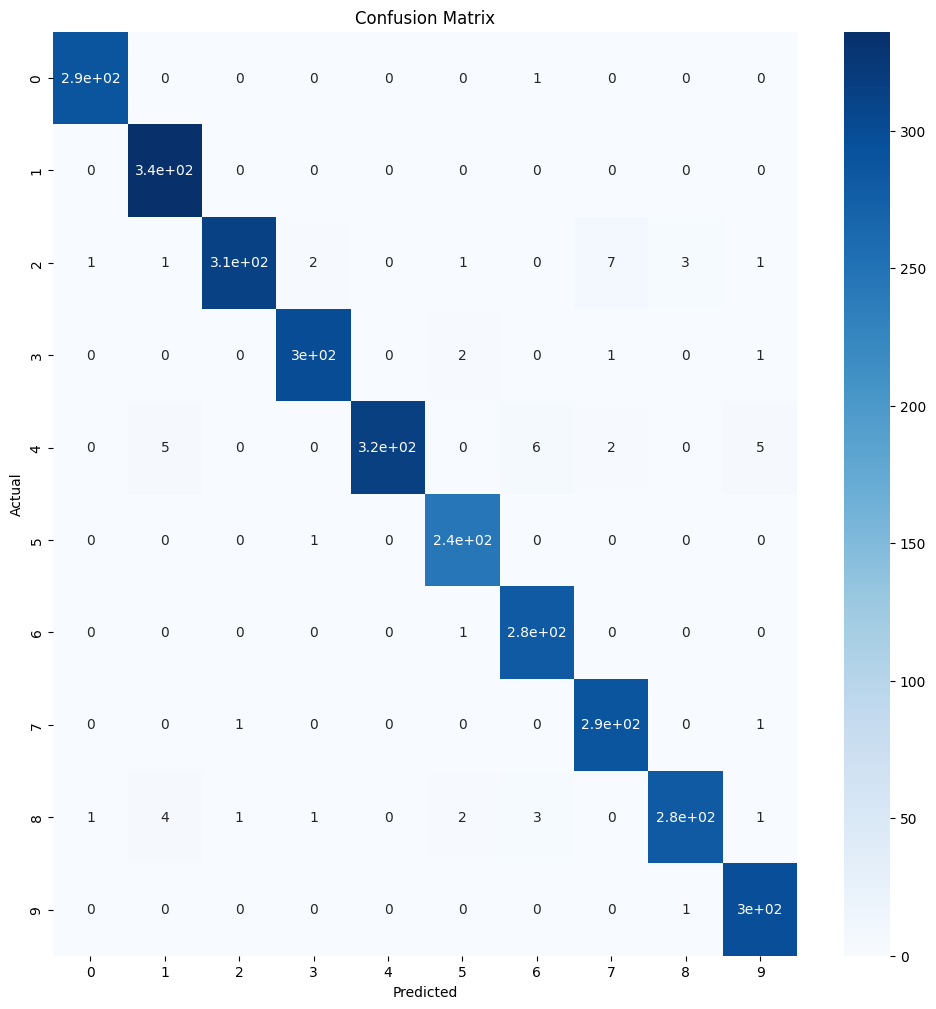

In [14]:
X_test = X_test.to(device)
y_test = y_test.to(device)

model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = nn.functional.softmax(test_logits, dim=1)
    test_preds = torch.argmax(test_probs, dim=1)

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print(classification_report(test_preds.cpu().numpy(), y_test.cpu().numpy()))

cm = confusion_matrix(test_preds.cpu().numpy(), y_test.cpu().numpy())

plt.figure(figsize=(12,12))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import torchvision.transforms as transforms
import torch


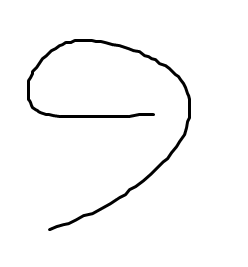

In [32]:

# Load your image
image_path = "./number_images/9.png"  # replace with your image path
img = Image.open(image_path).convert("L")  # convert to grayscale

# Transform to 28x28 and normalize like MNIST
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),  # converts to [0,1] float tensor
    transforms.Normalize((0.5,), (0.5,))  # normalize like your MNIST pipeline
])

img_tensor = transform(img)  # shape: [1, 28, 28]

img_tensor = img_tensor.unsqueeze(0)  # shape: [1, 1, 28, 28]


img_tensor = img_tensor.to(device)
img

In [33]:
model.eval()

# Disable gradient calculation for inference
with torch.no_grad():
    # Forward pass
    output = model(img_tensor)  # img_tensor shape: [1, 1, 28, 28]
    
    # Apply softmax to get probabilities (optional)
    probs = F.softmax(output, dim=1)
    
    # Get the predicted class
    pred_class = torch.argmax(probs, dim=1).item()

print("Predicted class:", pred_class)
print("Class probabilities:", probs.cpu().numpy())

Predicted class: 2
Class probabilities: [[0.02189792 0.00524306 0.6100002  0.14474316 0.01347654 0.0147548
  0.02010222 0.01609927 0.0489533  0.10472953]]


1    6742
7    6265
3    6131
2    5958
9    5949
0    5923
6    5918
8    5851
4    5842
5    5421
Name: count, dtype: int64